In [4]:
import xarray as xr
import rioxarray
from pathlib import Path
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from scipy.ndimage import median_filter, minimum_filter, maximum_filter, uniform_filter
import lightgbm as lgb 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.dummy import DummyClassifier
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix
from tqdm import tqdm
import joblib
from pathlib import Path

In [5]:
year = 2021
RAW_XY_FOLDERPATH = Path(f'../data/silver/Xy-{year}')

# Load data

In [6]:
raw_Xy = pd.read_parquet(RAW_XY_FOLDERPATH / "Xy.parquet")
metadata_df = pd.read_parquet(RAW_XY_FOLDERPATH / "metadata_df.parquet")

raw_Xy.head(1)

,red,green,blue,rededge,B06,B07,nir,B8A,swir11,swir22,...,gndvi_11x11_min,gndvi_11x11_max,gndvi_11x11_var,ndwi_11x11_median,ndwi_11x11_min,ndwi_11x11_max,ndwi_11x11_var,y,region,scl
0,0.145098,0.105882,0.07451,0.188235,0.203922,0.215686,0.215686,0.227451,0.309804,0.254902,...,0.00112,0.001609,0.000002,0.00679,0.006232,0.007676,0.000012,False,Upper East,NOT_VEGETATED


# Build Xy

In [7]:
def get_base_and_scl_and_obs_cnt_and_cloud_conf_and_advanced_features(X):
    features = ['blue', "green", "red", "rededge", "B06", "B07", "nir", "B8A", "swir11", "swir22"]
    features += ['scl', 'region']
    features += ['tci', 'ndvi', 'evi', 'evi2', 'ndre_b5', 'ndre_b6', 'ndre_b7', 'gndvi', 'ndwi']
    features += ['valid_observations']
    features += ['cloud_confidence']
    features += [e for e in X.columns if any(k in e for k in ['3x3', '5x5', '11x11'])]
    return X[features + ['y']]

Xy = get_base_and_scl_and_obs_cnt_and_cloud_conf_and_advanced_features(raw_Xy)
Xy.head(1)

,blue,green,red,rededge,B06,B07,nir,B8A,swir11,swir22,...,ndre_b7_11x11_var,gndvi_11x11_median,gndvi_11x11_min,gndvi_11x11_max,gndvi_11x11_var,ndwi_11x11_median,ndwi_11x11_min,ndwi_11x11_max,ndwi_11x11_var,y
0,0.07451,0.105882,0.145098,0.188235,0.203922,0.215686,0.215686,0.227451,0.309804,0.254902,...,1.662564e-07,0.001408,0.00112,0.001609,0.000002,0.00679,0.006232,0.007676,0.000012,False


# Prep hyperparam optimization

In [9]:
import numpy as np
import optuna
import lightgbm as lgb
from sklearn.model_selection import GroupKFold
from sklearn.metrics import f1_score, precision_score, recall_score

def optuna_objective_factory(X, y, groups, n_splits: int = 100):
    # Safely determine max possible splits based on unique groups
    unique_groups = len(np.unique(groups))
    actual_splits = min(n_splits, unique_groups)
    
    if actual_splits < n_splits:
        print(f"Warning: Requested {n_splits} splits, but only found {unique_groups} unique groups. Adjusting n_splits to {actual_splits}.")

    def objective(trial):
        param = {
            # 1. Core Learning Parameters
            'n_estimators': trial.suggest_int('n_estimators', 50, 500), 
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
            
            # 2. Tree Structure Limitations (Strictly constrained)
            'max_depth': trial.suggest_int('max_depth', 3, 8), 
            'num_leaves': trial.suggest_int('num_leaves', 10, 64), 
            'min_child_samples': trial.suggest_int('min_child_samples', 20, 200), 
            'min_split_gain': trial.suggest_float('min_split_gain', 0.0, 0.5),
            
            # 3. Bagging / Subsampling
            'subsample': trial.suggest_float('subsample', 0.5, 0.9), 
            'subsample_freq': trial.suggest_int('subsample_freq', 1, 5), 
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 0.9),
            
            # 4. Explicit Regularization
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
            
            # System settings
            'n_jobs': -1,
            'verbose': -1,
            'random_state': 42
        }
        
        gkf = GroupKFold(n_splits=actual_splits)
        
        # Initialize lists to store metrics and raw arrays
        true_f1s, true_precisions, true_recalls = [], [], []
        false_f1s, false_precisions, false_recalls = [], [], []
        all_yhat_vals, all_y_vals = [], []
        
        for train_idx, val_idx in gkf.split(X, y, groups):
            # Safe slicing regardless of whether X/y are pandas DataFrames/Series or numpy arrays
            X_train = X.iloc[train_idx]
            X_val = X.iloc[val_idx]
            y_train = y.iloc[train_idx]
            y_val = y.iloc[val_idx] 
            
            # Fit/predict
            model = lgb.LGBMClassifier(**param)
            model.fit(X_train, y_train)
            yhat_val = model.predict(X_val)
            
            # Calculate and append metrics
            true_f1s.append(f1_score(y_val, yhat_val, zero_division=0))
            true_precisions.append(precision_score(y_val, yhat_val, zero_division=0))
            true_recalls.append(recall_score(y_val, yhat_val, zero_division=0))

            false_f1s.append(f1_score(y_val, yhat_val, zero_division=0, pos_label=0))
            false_precisions.append(precision_score(y_val, yhat_val, zero_division=0, pos_label=0))
            false_recalls.append(recall_score(y_val, yhat_val, zero_division=0, pos_label=0))
            
            all_yhat_vals.append(yhat_val.tolist())
            all_y_vals.append(y_val.tolist())

        # Store tracked data as user attributes in the trial
        trial.set_user_attr('true_f1s', true_f1s)
        trial.set_user_attr('true_precisions', true_precisions)
        trial.set_user_attr('true_recalls', true_recalls)
        trial.set_user_attr('false_f1s', false_f1s)
        trial.set_user_attr('false_precisions', false_precisions)
        trial.set_user_attr('false_recalls', false_recalls)
        trial.set_user_attr('yhat_vals', all_yhat_vals)
        trial.set_user_attr('y_vals', all_y_vals)
        
        return np.median(true_f1s)

    return objective

# Train:test split

In [10]:
def compute_a(y):
    return y.sum() / len(y)

def compute_ahat(yhat, y_vals, yhat_vals):
    area_proportion_1 = yhat.sum() / len(yhat)
    area_proportion_0 = 1 - area_proportion_1
    
    # Figure out precision/false-omission-rate as the weighted-mean
    cms = [confusion_matrix(y_val, yhat_val, labels=[True, False]) for y_val, yhat_val in zip(y_vals, yhat_vals)] # (tp, fn), (fp, tn)
    tps = [e[0][0] for e in cms]
    fns = [e[0][1] for e in cms]
    tns = [e[1][1] for e in cms]
    fps = [e[1][0] for e in cms]

    # Figure out weighted-averaged TN, ...
    n_vals = np.array([len(e) for e in y_vals])
    tp = np.mean(tps)
    fn = np.mean(fns)
    fp = np.mean(fps)
    tn = np.mean(tns)

    # Compute validation set's metrics
    false_omission_rate = fn / (fn + tn)
    precision = tp / (tp + fp)

    # Compute adjusted unbiased area proportion
    ahat = (area_proportion_1 * precision) + (area_proportion_0 * false_omission_rate)

    # Compute Confidence Interval (Olofsson Variance)
    n_cocoa = tp + fp
    n_non_cocoa = fn + tn

    # Variance contribution from both strata
    var_cocoa = (area_proportion_1 ** 2) * (precision * (1 - precision)) / (n_cocoa - 1)
    var_non_cocoa = (area_proportion_0 ** 2) * (false_omission_rate * (1 - false_omission_rate)) / (n_non_cocoa - 1)
    
    # Standard Error
    se = np.sqrt(var_cocoa + var_non_cocoa)
    
    # Margin of Error for 95% Confidence Interval (Z-score = 1.96)
    margin_of_error = 1.96 * se
    
    ci_lower = max(0.0, ahat - margin_of_error) # Clamp at 0%
    ci_upper = min(1.0, ahat + margin_of_error) # Clamp at 100%

    return ahat, (ci_lower, ci_upper)

In [11]:
def train_test_split(Xy, metadata_df, region: str, test_size=0.2):
    """Split a train/test set, where all test samples are located within a region."""
    region_mask = Xy.region.apply(lambda x: x.lower()) == region

    if not region_mask.sum():
        raise ValueError(f'Region {region} not found.')

    # Discard not-in-region data
    Xy = Xy[region_mask]
    metadata_df = metadata_df[region_mask]
    print(f"Discarding out-of-region points: Kept {region_mask.sum()}/{len(region_mask)} ({region_mask.sum()/len(region_mask) * 100:.2f}%)")
    Xy = Xy.drop(columns=['region'])
    
    # Figure out which folds are for train/val and which for test
    region_fold_idxs = metadata_df.fold_idx[region_mask].unique()
    n_test_folds = int(np.floor(test_size * len(region_fold_idxs)))
    test_fold_idxs = np.random.choice(region_fold_idxs, size=n_test_folds, replace=False)
    test_mask = metadata_df.fold_idx.isin(test_fold_idxs)
    print(f"{len(test_fold_idxs)}/{len(region_fold_idxs)} regions for testing ({test_mask.sum()} points)")
    
    return Xy[~test_mask], metadata_df[~test_mask], Xy[test_mask], metadata_df[test_mask]

Xy_train, train_metadata_df, Xy_test, test_metadata_df = train_test_split(Xy, metadata_df, 'upper east', 0.2)
Xy_train.head(1)

Discarding out-of-region points: Kept 35926/944808 (3.80%)
200/1000 regions for testing (7319 points)


,blue,green,red,rededge,B06,B07,nir,B8A,swir11,swir22,...,ndre_b7_11x11_var,gndvi_11x11_median,gndvi_11x11_min,gndvi_11x11_max,gndvi_11x11_var,ndwi_11x11_median,ndwi_11x11_min,ndwi_11x11_max,ndwi_11x11_var,y
0,0.07451,0.105882,0.145098,0.188235,0.203922,0.215686,0.215686,0.227451,0.309804,0.254902,...,1.662564e-07,0.001408,0.00112,0.001609,0.000002,0.00679,0.006232,0.007676,0.000012,False


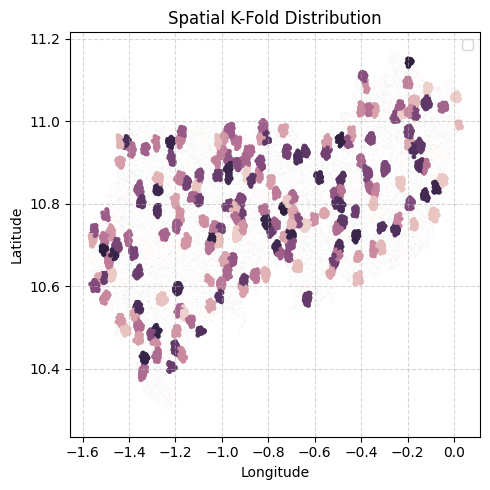

In [12]:
# Plot the folds
plt.figure(figsize=(5, 5))
sns.scatterplot(data=train_metadata_df, x='lon', y='lat', hue='fold_idx', palette='tab20', s=1, alpha=0.02, edgecolor=None)
sns.scatterplot(data=test_metadata_df, x='lon', y='lat', hue='fold_idx', color='r', s=10, alpha=1, edgecolor=None)

plt.title('Spatial K-Fold Distribution')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend([])
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

# Train

In [13]:
def train_test_lgbm(X_train, y_train, X_test, y_test, groups, n_splits=2, n_trials=3):
    print("Starting Optuna hyperparameter optimization...")
    study = optuna.create_study(direction="maximize") 
    study.optimize(optuna_objective_factory(X_train, y_train, groups, n_splits), n_trials=n_trials, show_progress_bar=True)
    
    # Build final model
    clf = lgb.LGBMClassifier(**study.best_params)
    clf.fit(X_train, y_train)
    
    yhat_train = clf.predict(X_train)
    yhat_test = clf.predict(X_test)

    # Validation-inferred correction
    yhat_vals = [np.array(e) for e in study.best_trial.user_attrs['yhat_vals']]
    y_vals = [np.array(e) for e in study.best_trial.user_attrs['y_vals']]
    ahat, (ci_lower, ci_upper) = compute_ahat(yhat_test, y_vals, yhat_vals)
    a = compute_a(y_test)
    print(f"Test region's estimated CAP: {ahat*100:.2f}% ({100 * ahat / a - 100:.2f}% off ETHZ's estimate)")
    print(f"95% Confidence Interval: [{ci_lower*100:.2f}%, {ci_upper*100:.2f}%]")
    
    print("\n--- OPTIMIZED MODEL EVALUATION ---")
    print("TRAIN")
    print(f"- F1: {f1_score(y_train, yhat_train, zero_division=0):.4f}")
    print(f"- Precision: {precision_score(y_train, yhat_train, zero_division=0):.4f}")
    print(f"- Recall: {recall_score(y_train, yhat_train, zero_division=0):.4f}")
    
    print("\nTEST")
    print(f"- F1: {f1_score(y_test, yhat_test, zero_division=0):.4f}")
    print(f"- Precision: {precision_score(y_test, yhat_test, zero_division=0):.4f}")
    print(f"- Recall: {recall_score(y_test, yhat_test, zero_division=0):.4f}")

    return clf, study.best_trial.user_attrs

In [14]:
def train_region(Xy, metadata_df, region, test_size=0.2, n_splits=2, n_trials=1):
    
    # Get train:test
    Xy_train, train_metadata_df, Xy_test, test_metadata_df = train_test_split(Xy, metadata_df, region.lower(), test_size)    
    X_train, y_train = Xy_train.drop(columns=['y']), Xy_train.y
    X_test, y_test = Xy_test.drop(columns=['y']), Xy_test.y

    # Train
    clf, user_attrs = train_test_lgbm(X_train, y_train, X_test, y_test, train_metadata_df.fold_idx, n_splits=n_splits, n_trials=n_trials);
    
    # Dump
    payload = {
        'X_train': X_train,
        'y_train': y_train,
        'metadata_df_train':  train_metadata_df,
        'X_test': X_test,
        'y_test': y_test,
        'metadata_df_test':  test_metadata_df,
        'clf': clf,
        "user_attrs": user_attrs,
    }
    
    joblib.dump(payload, f'trained-{region.lower()}-2021.joblib')

In [16]:
train_region(Xy, metadata_df, 'ashanti', 0.5, n_splits=10, n_trials=20)

[I 2026-06-29 11:45:46,605] A new study created in memory with name: no-name-6f0eba14-a0d1-4369-bd1d-23fe53e584b2


Discarding out-of-region points: Kept 99065/944808 (10.49%)
500/1000 regions for testing (49733 points)
Starting Optuna hyperparameter optimization...


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-06-29 11:45:54,009] Trial 0 finished with value: 0.0 and parameters: {'n_estimators': 54, 'learning_rate': 0.011847879317950121, 'max_depth': 3, 'num_leaves': 25, 'min_child_samples': 186, 'min_split_gain': 0.16529475759476764, 'subsample': 0.8488378984681911, 'subsample_freq': 4, 'colsample_bytree': 0.7935819655686667, 'reg_alpha': 0.038248340875838935, 'reg_lambda': 0.003314614327445467}. Best is trial 0 with value: 0.0.
[I 2026-06-29 11:46:06,255] Trial 1 finished with value: 0.790111389577657 and parameters: {'n_estimators': 93, 'learning_rate': 0.19616096825233206, 'max_depth': 6, 'num_leaves': 16, 'min_child_samples': 140, 'min_split_gain': 0.07662460596632298, 'subsample': 0.6549143896944453, 'subsample_freq': 1, 'colsample_bytree': 0.6994637791054299, 'reg_alpha': 1.5510590967855265e-05, 'reg_lambda': 8.329325052793519e-08}. Best is trial 1 with value: 0.790111389577657.
[I 2026-06-29 11:47:03,087] Trial 2 finished with value: 0.7807809275639106 and parameters: {'n_esti

In [17]:
train_region(Xy, metadata_df, 'western north', 0.5, n_splits=10, n_trials=20)

[I 2026-06-29 11:55:14,573] A new study created in memory with name: no-name-72fe02fd-076e-4667-8b41-05c6cd4dbd8b


Discarding out-of-region points: Kept 33339/944808 (3.53%)
500/1000 regions for testing (16816 points)
Starting Optuna hyperparameter optimization...


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-06-29 11:55:25,499] Trial 0 finished with value: 0.8326110509209101 and parameters: {'n_estimators': 143, 'learning_rate': 0.07179969147108552, 'max_depth': 5, 'num_leaves': 18, 'min_child_samples': 69, 'min_split_gain': 0.13325200446194257, 'subsample': 0.8766831326604492, 'subsample_freq': 3, 'colsample_bytree': 0.8327203784673027, 'reg_alpha': 4.1760358938719255e-06, 'reg_lambda': 2.0835712259504842e-08}. Best is trial 0 with value: 0.8326110509209101.
[I 2026-06-29 11:55:47,233] Trial 1 finished with value: 0.8359144542772862 and parameters: {'n_estimators': 422, 'learning_rate': 0.04817922220288452, 'max_depth': 5, 'num_leaves': 47, 'min_child_samples': 42, 'min_split_gain': 0.31108975634729347, 'subsample': 0.8010635388961358, 'subsample_freq': 1, 'colsample_bytree': 0.5262836010767288, 'reg_alpha': 3.509187767548525e-08, 'reg_lambda': 0.00013093197721558914}. Best is trial 1 with value: 0.8359144542772862.
[I 2026-06-29 11:56:03,478] Trial 2 finished with value: 0.833848

In [18]:
train_region(Xy, metadata_df, 'western', 0.5, n_splits=10, n_trials=20)

[I 2026-06-29 11:59:35,713] A new study created in memory with name: no-name-67b5b40e-3e8b-4c1b-b227-39c6ed727a38


Discarding out-of-region points: Kept 38855/944808 (4.11%)
500/1000 regions for testing (19525 points)
Starting Optuna hyperparameter optimization...


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-06-29 11:59:39,663] Trial 0 finished with value: 0.7953240414480724 and parameters: {'n_estimators': 87, 'learning_rate': 0.07907305136504146, 'max_depth': 3, 'num_leaves': 25, 'min_child_samples': 176, 'min_split_gain': 0.03658637733810005, 'subsample': 0.7713670823599919, 'subsample_freq': 2, 'colsample_bytree': 0.6880532984909018, 'reg_alpha': 3.0501936435249298e-05, 'reg_lambda': 0.1718408546114188}. Best is trial 0 with value: 0.7953240414480724.
[I 2026-06-29 11:59:53,551] Trial 1 finished with value: 0.8233799300440762 and parameters: {'n_estimators': 326, 'learning_rate': 0.1009275761315768, 'max_depth': 5, 'num_leaves': 29, 'min_child_samples': 91, 'min_split_gain': 0.34713210693365687, 'subsample': 0.8436072096984479, 'subsample_freq': 4, 'colsample_bytree': 0.5295919445358518, 'reg_alpha': 4.9863760382813895, 'reg_lambda': 0.012844915624184796}. Best is trial 1 with value: 0.8233799300440762.
[I 2026-06-29 12:00:02,105] Trial 2 finished with value: 0.8175388818831442

In [19]:
train_region(Xy, metadata_df, 'ahafo', 0.5, n_splits=10, n_trials=20)

[I 2026-06-29 12:03:36,003] A new study created in memory with name: no-name-351b95f0-2389-4c40-a9db-80db567692fe


Discarding out-of-region points: Kept 20436/944808 (2.16%)
500/1000 regions for testing (10166 points)
Starting Optuna hyperparameter optimization...


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-06-29 12:03:41,098] Trial 0 finished with value: 0.8393893784001942 and parameters: {'n_estimators': 287, 'learning_rate': 0.13303827553462486, 'max_depth': 3, 'num_leaves': 19, 'min_child_samples': 185, 'min_split_gain': 0.1156031963745845, 'subsample': 0.8429508615076946, 'subsample_freq': 5, 'colsample_bytree': 0.6434800214072921, 'reg_alpha': 1.3959154740950096e-07, 'reg_lambda': 0.6404349764243217}. Best is trial 0 with value: 0.8393893784001942.
[I 2026-06-29 12:03:56,473] Trial 1 finished with value: 0.8540392539288757 and parameters: {'n_estimators': 347, 'learning_rate': 0.06089675266947131, 'max_depth': 7, 'num_leaves': 41, 'min_child_samples': 45, 'min_split_gain': 0.42175649437539886, 'subsample': 0.8150810789077143, 'subsample_freq': 2, 'colsample_bytree': 0.6641999099678721, 'reg_alpha': 0.22864157167611882, 'reg_lambda': 0.030447897871259597}. Best is trial 1 with value: 0.8540392539288757.
[I 2026-06-29 12:04:05,282] Trial 2 finished with value: 0.82030852629027

In [20]:
train_region(Xy, metadata_df, 'central', 0.5, n_splits=10, n_trials=20)

[I 2026-06-29 12:06:34,902] A new study created in memory with name: no-name-dbb9825d-35e2-41a5-a31a-dcdc867cf08c


Discarding out-of-region points: Kept 33440/944808 (3.54%)
500/1000 regions for testing (16970 points)
Starting Optuna hyperparameter optimization...


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-06-29 12:06:43,574] Trial 0 finished with value: 0.774561567454755 and parameters: {'n_estimators': 142, 'learning_rate': 0.058654445770218236, 'max_depth': 7, 'num_leaves': 52, 'min_child_samples': 75, 'min_split_gain': 0.3755401703380708, 'subsample': 0.5277984990415132, 'subsample_freq': 1, 'colsample_bytree': 0.560640565013151, 'reg_alpha': 2.2571147493127247e-07, 'reg_lambda': 0.0032942277920264924}. Best is trial 0 with value: 0.774561567454755.
[I 2026-06-29 12:06:57,239] Trial 1 finished with value: 0.773346911182043 and parameters: {'n_estimators': 491, 'learning_rate': 0.018744338997623424, 'max_depth': 5, 'num_leaves': 60, 'min_child_samples': 194, 'min_split_gain': 0.2014613002503639, 'subsample': 0.5351936568070966, 'subsample_freq': 2, 'colsample_bytree': 0.47475482312644907, 'reg_alpha': 4.032871082405069e-08, 'reg_lambda': 1.3690760263315234e-06}. Best is trial 0 with value: 0.774561567454755.
[I 2026-06-29 12:07:03,220] Trial 2 finished with value: 0.7700379521

In [21]:
train_region(Xy, metadata_df, 'eastern', 0.5, n_splits=10, n_trials=20)

[I 2026-06-29 12:11:13,338] A new study created in memory with name: no-name-051567c8-1723-42dd-9f24-2d42e8cdfb4a


Discarding out-of-region points: Kept 70356/944808 (7.45%)
500/1000 regions for testing (35032 points)
Starting Optuna hyperparameter optimization...


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-06-29 12:11:33,978] Trial 0 finished with value: 0.649520862368995 and parameters: {'n_estimators': 425, 'learning_rate': 0.02058378776296886, 'max_depth': 4, 'num_leaves': 48, 'min_child_samples': 92, 'min_split_gain': 0.48155926390563447, 'subsample': 0.5551684162883328, 'subsample_freq': 5, 'colsample_bytree': 0.8120481784117071, 'reg_alpha': 0.0007382259443361253, 'reg_lambda': 1.1344694437473954}. Best is trial 0 with value: 0.649520862368995.
[I 2026-06-29 12:11:50,142] Trial 1 finished with value: 0.6831544959671432 and parameters: {'n_estimators': 250, 'learning_rate': 0.1404622525380543, 'max_depth': 8, 'num_leaves': 20, 'min_child_samples': 186, 'min_split_gain': 0.19127910358254124, 'subsample': 0.5683147043058274, 'subsample_freq': 2, 'colsample_bytree': 0.5556469849529839, 'reg_alpha': 0.004284588236777614, 'reg_lambda': 7.038148625067781e-07}. Best is trial 1 with value: 0.6831544959671432.
[I 2026-06-29 12:12:04,501] Trial 2 finished with value: 0.593744924168802

# Use TCA
https://en.wikipedia.org/wiki/Tasseled_cap_transformation

# Use clustering min ?